<a href="https://colab.research.google.com/github/rigayus24ti-cmd/Pertemuan-4-Statistika./blob/main/Pertemuan_4_Statistika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [51]:
import pandas as pd
from google.colab import files

In [52]:
import pandas as pd
from google.colab import files

# 1. Upload file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 2. Baca file Excel mulai dari header tabel
data = pd.read_excel(filename, header=5)

# 3. Hapus kolom pertama yang kosong (NaN)
data = data.dropna(how='all', axis=1)

# 4. Ambil 5 kolom pertama dan beri nama kolom yang bersih
data = data.iloc[:, :5]
data.columns = ['NIM', 'Name', 'KUIS', 'UTS', 'UAS']

# 5. Konversi kolom nilai menjadi tipe data angka (mencegah error)
for col in ['KUIS', 'UTS', 'UAS']:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# 6. Hitung Nilai Akhir sesuai rumus (15% Kuis + 35% UTS + 50% UAS)
data['Nilai'] = (data['KUIS'] * 0.15) + (data['UTS'] * 0.35) + (data['UAS'] * 0.50)

# 7. Tentukan Grade sesuai skala tabel acuan
def get_grade(nilai):
    if nilai >= 80:
        return 'A'
    elif nilai >= 75:
        return 'AB'
    elif nilai >= 68:
        return 'B'
    elif nilai >= 60:
        return 'BC'
    elif nilai >= 50:
        return 'C'
    else:
        return 'F'

data['Grade'] = data['Nilai'].apply(get_grade)

# Tampilkan tabel yang sudah rapi dan terisi penuh
display(data)

Saving Latihan Penyajian Data dan Stat Des dg Excel.xlsx to Latihan Penyajian Data dan Stat Des dg Excel (20).xlsx


,NIM,Name,KUIS,UTS,UAS,Nilai,Grade
0,ID,Name,NaN,NaN,NaN,NaN,F
1,120001,John Doe,85.0,78.0,90.0,85.05,A
2,120005,Jane Smith,92.0,88.0,94.0,91.60,A
3,120017,Michael Johnson,48.0,65.0,56.0,57.95,C
4,120018,Emily Brown,90.0,85.0,88.0,87.25,A
5,120022,Daniel Martinez,75.0,80.0,77.0,77.75,AB
6,120024,Sarah Wilson,88.0,70.0,65.0,70.20,B
7,120025,David Garcia,75.0,70.0,75.0,73.25,B
8,120027,Jessica Lee,95.0,91.0,96.0,94.10,A
9,120034,Matthew Davis,79.0,84.0,78.0,80.25,A


In [53]:
# 6. Pembuatan tabel frekuensi
datafrq = pd.crosstab(index=data["Grade"], columns="Frekuensi")
print(datafrq)

col_0  Frekuensi
Grade           
A             14
AB             5
B              3
BC             2
C              5
F              2


<Axes: xlabel='Grade'>

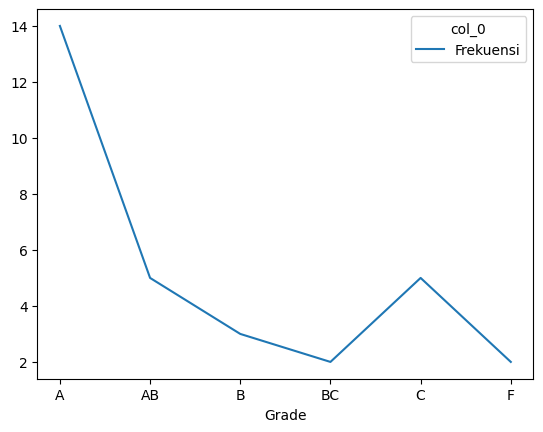

In [54]:
#Grafik Garis
datafrq.plot()

<Axes: xlabel='Grade'>

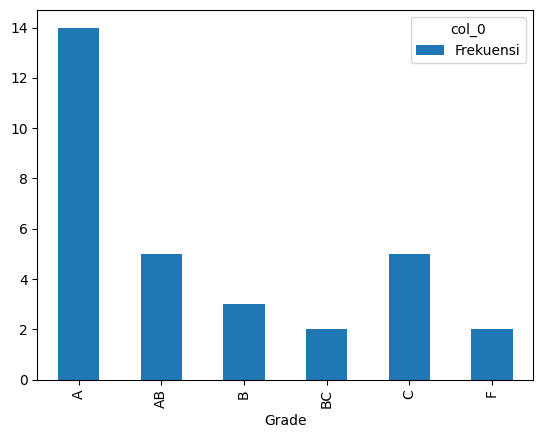

In [55]:
#Grafik batang
datafrq.plot(kind='bar')

<Axes: ylabel='Frekuensi'>

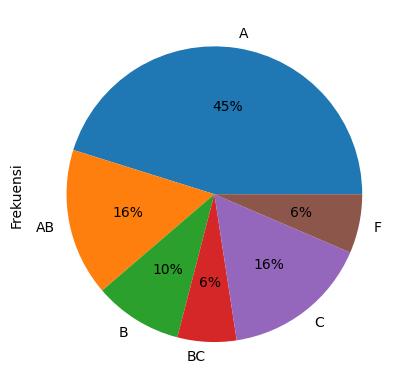

In [56]:
#Pie Chart
datafrq.plot(kind='pie', y='Frekuensi', autopct='%1.0f%%', legend=False)

In [57]:
import pandas as pd
from google.colab import files

# 1. Upload file
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 2. Baca file Excel mulai dari header asli (header=5)
dataraw = pd.read_excel(filename, header=5)

# 3. Bersihkan kolom kosong
dataraw = dataraw.dropna(how='all', axis=1)

# 4. Ambil 5 kolom utama dan tentukan nama kolom
dataraw = dataraw.iloc[:, :5]
dataraw.columns = ['NIM', 'Name', 'KUIS', 'UTS', 'UAS']

# 5. Konversi kolom ke bentuk angka
for col in ['KUIS', 'UTS', 'UAS']:
    dataraw[col] = pd.to_numeric(dataraw[col], errors='coerce')

# 6. Hapus baris teks header yang tersisa jika ada
dataraw = dataraw.dropna(subset=['KUIS', 'UTS', 'UAS'])

# 7. BUAT KOLOM 'Nilai' (Langkah penting agar tidak KeyError)
dataraw['Nilai'] = (dataraw['KUIS'] * 0.10) + (dataraw['UTS'] * 0.40) + (dataraw['UAS'] * 0.50)

# 8. Hitung Statistika Deskriptif
dt = dataraw["Nilai"]
stats = dt.describe()
stats['Standard Error'] = dt.sem()
stats['Median'] = dt.median()
stats['Mode'] = dt.mode().iloc[0]
stats['variance'] = dt.var()
stats['range'] = dt.max() - dt.min()
stats['skewness'] = dt.skew()
stats['kurtosis'] = dt.kurtosis()

print(stats)

Saving Latihan Penyajian Data dan Stat Des dg Excel.xlsx to Latihan Penyajian Data dan Stat Des dg Excel (21).xlsx
count              30.000000
mean               76.206667
std                13.332070
min                47.300000
25%                67.725000
50%                79.000000
75%                86.800000
max                93.900000
Standard Error      2.434092
Median             79.000000
Mode               77.500000
variance          177.744092
range              46.600000
skewness           -0.604904
kurtosis           -0.683369
Name: Nilai, dtype: float64
